# Week 5: Additional Models

### Goals:
- Try Decision Tree and Random Forest regressors
- Compare their test R^2 against baseline
- Document model behavior (strengths/weaknesses)

In [30]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from pathlib import Path
from sklearn.ensemble import RandomForestRegressor
from matplotlib.ticker import StrMethodFormatter
from sklearn.tree import DecisionTreeRegressor
np.random.seed(42)
random.seed(42)

In [5]:
# loading in data

filepath = r"C:\Users\julia\downloads\IDX_summer_internship"
train_df = pd.read_csv(filepath + r"\train_cleaned.csv", low_memory=False)
test_df = pd.read_csv(filepath + r"\test_cleaned.csv", low_memory=False)

drop_cols = [
    "CloseDate", "ListPrice", "OriginalListPrice",
    "ListingKey", "ListingKeyNumeric", "DaysOnMarket", "HighSchoolDistrict"
]

x_train = train_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
x_test = test_df.drop(columns=["ClosePrice"] + drop_cols, errors="ignore")
y_train = train_df["ClosePrice"]
y_test = test_df["ClosePrice"]

print(f"X_train: {x_train.shape}")
print(f"X_test: {x_test.shape}")

X_train: (313288, 48)
X_test: (11844, 48)


In [7]:
# metrics function
def evaluate_model(y_true, y_pred, label="Model"):
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    mdape = np.median(np.abs((y_true - y_pred) / y_true)) * 100
    
    print(f"\n{label}")
    print(f"R²:    {r2:.4f}")
    print(f"RMSE:  ${rmse:,.0f}")
    print(f"MAE:   ${mae:,.0f}")
    print(f"MAPE:  {mape:.2f}%")
    print(f"MdAPE: {mdape:.2f}%")
    
    return {"Model": label, "R2": r2, "RMSE": rmse, 
            "MAE": mae, "MAPE": mape, "MdAPE": mdape}

In [15]:
# rerunning baseline linear regression for comparison
lr = LinearRegression()
lr.fit(x_train, y_train)
y_pred_lr = lr.predict(x_test)
results_lr = evaluate_model(y_test, y_pred_lr, label="Linear Regression (Baseline)")
print(results_lr)


Linear Regression (Baseline)
R²:    0.4774
RMSE:  $663,278
MAE:   $438,910
MAPE:  42.95%
MdAPE: 29.92%
{'Model': 'Linear Regression (Baseline)', 'R2': 0.47737439238187807, 'RMSE': 663278.4873347576, 'MAE': 438909.9634065761, 'MAPE': 42.951906587811656, 'MdAPE': 29.924855590335618}


# Decision Tree
A decision tree learns to predict prices by working with feature values in a branching structure. Decision tree tends to overfit, as it grows without limits without manual limits, ex: max_depth. A max_depth of 10 is a reasonable middle ground for trainig which can be optimized later for hyperparameter training. 

NOTE: max_depth may be tuned in hyperparameter training

In [21]:
# decision tree
dt = DecisionTreeRegressor(max_depth=10, random_state=42)
dt.fit(x_train, y_train)
y_pred_dt = dt.predict(x_test)
results_dt = evaluate_model(y_test, y_pred_dt, label="Decision Tree")

# check for overfitting - compare train vs test R²
print(f"\nDecision Tree Train R²: {r2_score(y_train, dt.predict(x_train)):.4f}")
print(f"Decision Tree Test R²:  {r2_score(y_test, y_pred_dt):.4f}")


Decision Tree
R²:    0.7844
RMSE:  $425,975
MAE:   $245,890
MAPE:  19.82%
MdAPE: 13.85%

Decision Tree Train R²: 0.8175
Decision Tree Test R²:  0.7844


# Random Forest 
A Random Forest is a large collection of decision trees that work together on a prediction, ex: 100 different trees and an average of their answers. As before, n_estimators is set to 100 as a starting value but can be tuned as a hyperparameter. Max_depth is set to 15 under this principle as well.

In [32]:
# random forest
# n_estimators = number of trees, can be tuned as a hyperparameter
rf = RandomForestRegressor(n_estimators=100, max_depth=15, random_state=42, n_jobs=-1)
rf.fit(x_train, y_train)
y_pred_rf = rf.predict(x_test)
results_rf = evaluate_model(y_test, y_pred_rf, label="Random Forest")

# check for overfitting
print(f"\nRandom Forest Train R²: {r2_score(y_train, rf.predict(x_train)):.4f}")
print(f"Random Forest Test R²:  {r2_score(y_test, y_pred_rf):.4f}")


Random Forest
R²:    0.8809
RMSE:  $316,576
MAE:   $170,737
MAPE:  13.17%
MdAPE: 8.97%

Random Forest Train R²: 0.9466
Random Forest Test R²:  0.8809


# Comparison Table of Linear Regression, Random Forest, and Decision Tree metrics

In [34]:
# side by side comparison
results_table = pd.DataFrame([results_lr, results_dt, results_rf])
results_table = results_table.set_index("Model")
results_table = results_table.round(4)
print(results_table)

                                  R2         RMSE          MAE     MAPE  \
Model                                                                     
Linear Regression (Baseline)  0.4774  663278.4873  438909.9634  42.9519   
Decision Tree                 0.7844  425974.8581  245890.2715  19.8206   
Random Forest                 0.8809  316576.4662  170736.6832  13.1680   

                                MdAPE  
Model                                  
Linear Regression (Baseline)  29.9249  
Decision Tree                 13.8514  
Random Forest                  8.9712  


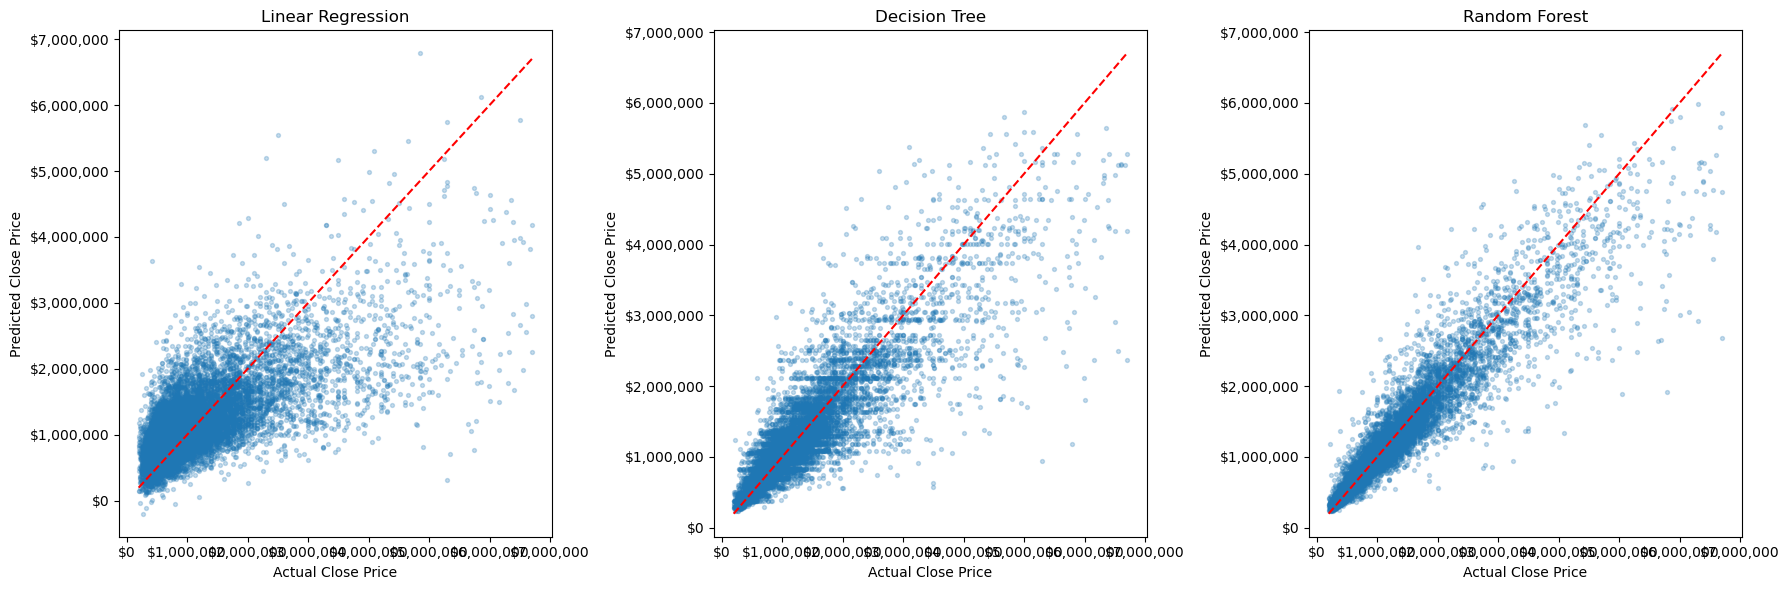

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

models = [
    ("Linear Regression", y_pred_lr),
    ("Decision Tree", y_pred_dt),
    ("Random Forest", y_pred_rf)
]

for ax, (name, preds) in zip(axes, models):
    ax.scatter(y_test, preds, alpha=0.25, s=8)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            color="red", linestyle="--")
    ax.set_xlabel("Actual Close Price")
    ax.set_ylabel("Predicted Close Price")
    ax.set_title(name)
    ax.xaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))
    ax.yaxis.set_major_formatter(StrMethodFormatter('${x:,.0f}'))

plt.tight_layout()
plt.savefig(filepath + r"\model_comparison_plots.png", dpi=150, bbox_inches='tight')
plt.show()

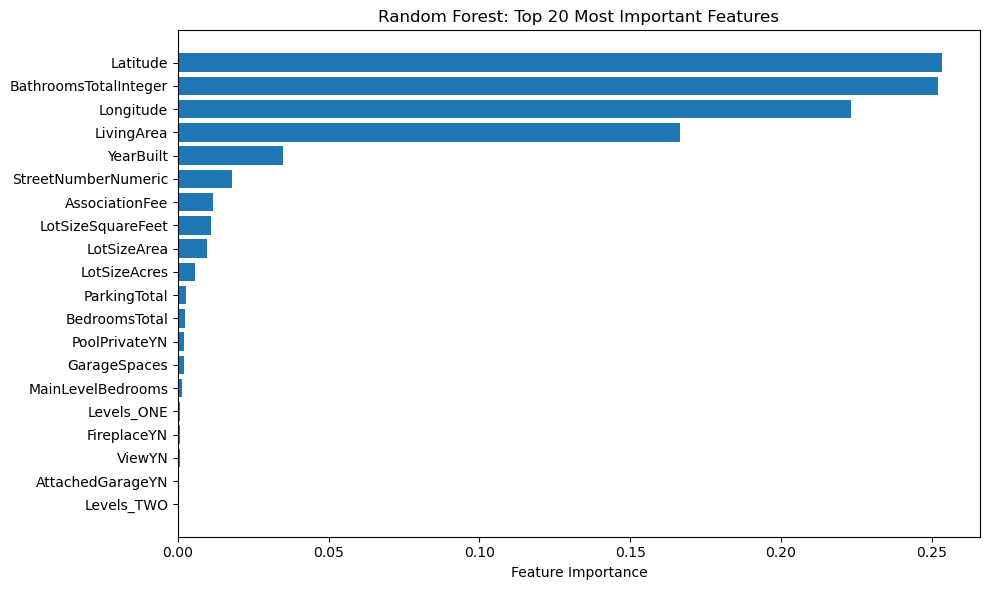

                  Feature  Importance
2                Latitude    0.253329
10  BathroomsTotalInteger    0.251982
3               Longitude    0.223087
4              LivingArea    0.166577
8               YearBuilt    0.034799
9     StreetNumberNumeric    0.017837
18         AssociationFee    0.011629
19      LotSizeSquareFeet    0.011006
14            LotSizeArea    0.009565
7            LotSizeAcres    0.005796
6            ParkingTotal    0.002808
11          BedroomsTotal    0.002298
1           PoolPrivateYN    0.001957
17           GarageSpaces    0.001877
15      MainLevelBedrooms    0.001297
33             Levels_ONE    0.000813
12            FireplaceYN    0.000762
0                  ViewYN    0.000531
5        AttachedGarageYN    0.000484
43             Levels_TWO    0.000395


In [36]:
# feature importance
importance_df = pd.DataFrame({
    "Feature": x_train.columns,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False).head(20)

plt.figure(figsize=(10, 6))
plt.barh(importance_df["Feature"][::-1], importance_df["Importance"][::-1])
plt.xlabel("Feature Importance")
plt.title("Random Forest: Top 20 Most Important Features")
plt.tight_layout()
plt.show()

print(importance_df)